In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
gen = pd.read_csv('C:/Users/chint/solar-iot-monitor/data/Plant_1_Generation_Data.csv')
weather = pd.read_csv('C:/Users/chint/solar-iot-monitor/data/Plant_1_Weather_Sensor_Data.csv')

# Basic info
print("Generation Data Shape:", gen.shape)
print("Weather Data Shape:", weather.shape)
print("\n--- Generation Data ---")
print(gen.head())
print("\n--- Weather Data ---")
print(weather.head())

Generation Data Shape: (68778, 7)
Weather Data Shape: (3182, 6)

--- Generation Data ---
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  

--- Weather Data ---
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.93

In [6]:
# Check for missing values and data types
print("=== Generation Data Info ===")
print(gen.info())
print("\nMissing values:\n", gen.isnull().sum())

print("\n=== Weather Data Info ===")
print(weather.info())
print("\nMissing values:\n", weather.isnull().sum())

print("\n=== Generation Data Stats ===")
print(gen.describe())

=== Generation Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 5.7 MB
None

Missing values:
 DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

=== Weather Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_

In [7]:
# Convert DATE_TIME to proper datetime format
gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

# Remove nighttime rows (where irradiation is 0)
weather_day = weather[weather['IRRADIATION'] > 0]
gen_day = gen[gen['DC_POWER'] > 0]

print("Generation rows (daytime only):", len(gen_day))
print("Weather rows (daytime only):", len(weather_day))

# Merge both dataframes on DATE_TIME
merged = pd.merge(gen_day, weather_day[['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']], 
                  on='DATE_TIME', how='inner')

print("\nMerged Data Shape:", merged.shape)
print(merged.head())

Generation rows (daytime only): 36827
Weather rows (daytime only): 1757

Merged Data Shape: (36823, 10)
            DATE_TIME  PLANT_ID       SOURCE_KEY   DC_POWER  AC_POWER  \
0 2020-05-15 06:00:00   4135001  1BY6WEcLGh8j5v7  37.142857  3.585714   
1 2020-05-15 06:00:00   4135001  1IF53ai7Xc0U56Y  53.500000  5.162500   
2 2020-05-15 06:00:00   4135001  3PZuoBAID5Wc2HD  58.000000  5.585714   
3 2020-05-15 06:00:00   4135001  7JYdWkrLSPkdwr4  58.428571  5.628571   
4 2020-05-15 06:00:00   4135001  McdE0feGgRqW7Ca  54.375000  5.250000   

   DAILY_YIELD  TOTAL_YIELD  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0          0.0    6259559.0            24.088446           22.206757   
1          0.0    6183645.0            24.088446           22.206757   
2          0.0    6987759.0            24.088446           22.206757   
3          0.0    7602960.0            24.088446           22.206757   
4          0.0    7158964.0            24.088446           22.206757   

   IRRADIATION  
0     0

In [8]:
# Feature Engineering

# 1. Performance Ratio — actual vs theoretical output
# Higher irradiation should mean higher power. Ratio < threshold = possible fault
merged['PERFORMANCE_RATIO'] = merged['AC_POWER'] / (merged['IRRADIATION'] * 100 + 1e-6)

# 2. DC to AC conversion efficiency
# A healthy inverter converts DC to AC efficiently. Drop = inverter fault
merged['DC_AC_EFFICIENCY'] = merged['AC_POWER'] / (merged['DC_POWER'] + 1e-6)

# 3. Temperature corrected power
# High module temperature reduces output — we account for that here
merged['TEMP_CORRECTED_POWER'] = merged['AC_POWER'] / (1 - 0.004 * (merged['MODULE_TEMPERATURE'] - 25))

print("New features added:")
print(merged[['PERFORMANCE_RATIO', 'DC_AC_EFFICIENCY', 'TEMP_CORRECTED_POWER']].describe())

New features added:
       PERFORMANCE_RATIO  DC_AC_EFFICIENCY  TEMP_CORRECTED_POWER
count       36823.000000      36823.000000          36823.000000
mean           13.400477          0.097719            629.354490
std             1.493174          0.000458            422.796703
min             0.949061          0.095552              0.845656
25%            12.742850          0.097579            236.064693
50%            13.555464          0.097845            624.138887
75%            14.270909          0.098014            956.326233
max            27.640982          0.106592           1635.968118


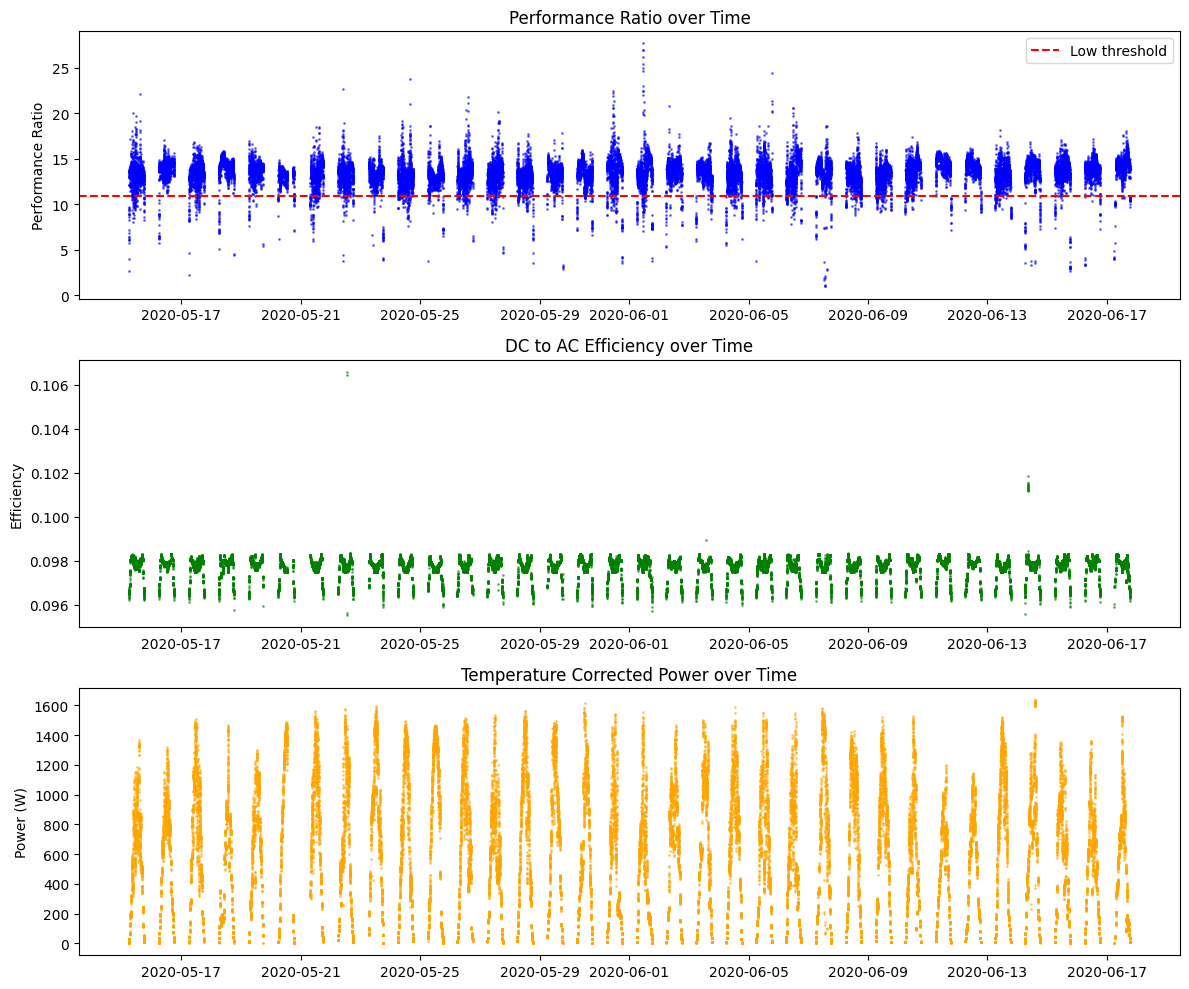

Plot saved!


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Performance Ratio over time
axes[0].scatter(merged['DATE_TIME'], merged['PERFORMANCE_RATIO'], s=1, alpha=0.5, color='blue')
axes[0].set_title('Performance Ratio over Time')
axes[0].set_ylabel('Performance Ratio')
axes[0].axhline(y=merged['PERFORMANCE_RATIO'].quantile(0.05), color='red', linestyle='--', label='Low threshold')
axes[0].legend()

# DC to AC Efficiency
axes[1].scatter(merged['DATE_TIME'], merged['DC_AC_EFFICIENCY'], s=1, alpha=0.5, color='green')
axes[1].set_title('DC to AC Efficiency over Time')
axes[1].set_ylabel('Efficiency')

# Temperature Corrected Power
axes[2].scatter(merged['DATE_TIME'], merged['TEMP_CORRECTED_POWER'], s=1, alpha=0.5, color='orange')
axes[2].set_title('Temperature Corrected Power over Time')
axes[2].set_ylabel('Power (W)')

plt.tight_layout()
plt.savefig('C:/Users/chint/solar-iot-monitor/data/feature_plots.png')
plt.show()
print("Plot saved!")

In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np

# Prepare features for the model
features = ['PERFORMANCE_RATIO', 'DC_AC_EFFICIENCY', 'TEMP_CORRECTED_POWER']
X = merged[features].copy()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
# contamination = expected % of anomalies (we assume ~5% of readings are faults)
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(X_scaled)

# Predict — Isolation Forest returns 1 (normal) or -1 (anomaly)
merged['ANOMALY'] = model.predict(X_scaled)
merged['ANOMALY_LABEL'] = merged['ANOMALY'].map({1: 'Normal', -1: 'Fault'})

# Summary
fault_count = (merged['ANOMALY'] == -1).sum()
normal_count = (merged['ANOMALY'] == 1).sum()
print(f"Total readings: {len(merged)}")
print(f"Normal readings: {normal_count}")
print(f"Faults detected: {fault_count} ({fault_count/len(merged)*100:.1f}%)")

Total readings: 36823
Normal readings: 34981
Faults detected: 1842 (5.0%)


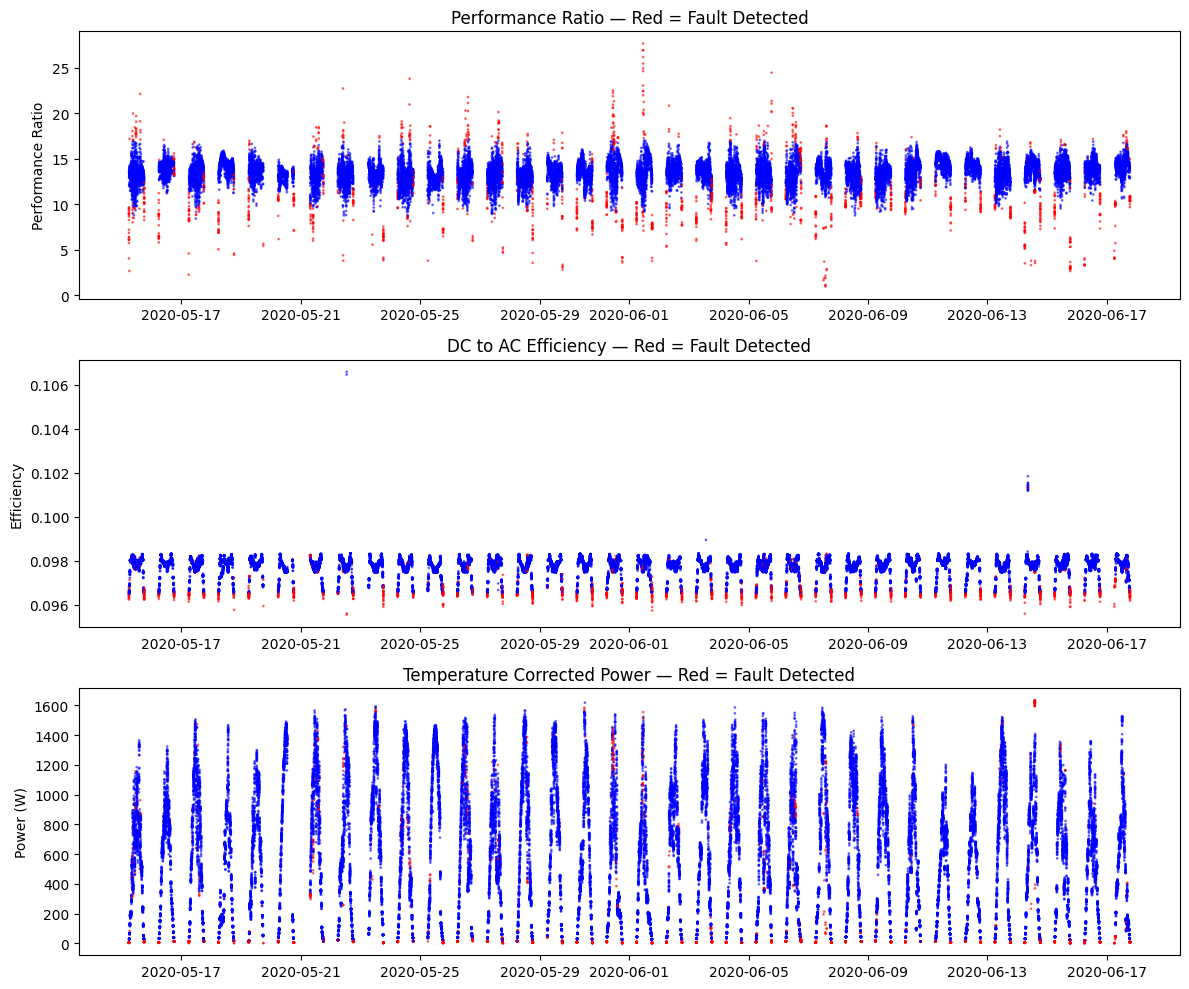

Fault detection plot saved!


In [11]:
# Plot faults vs normal readings
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

colors = merged['ANOMALY_LABEL'].map({'Normal': 'blue', 'Fault': 'red'})

# Performance Ratio
axes[0].scatter(merged['DATE_TIME'], merged['PERFORMANCE_RATIO'], 
                c=colors, s=1, alpha=0.5)
axes[0].set_title('Performance Ratio — Red = Fault Detected')
axes[0].set_ylabel('Performance Ratio')

# DC to AC Efficiency
axes[1].scatter(merged['DATE_TIME'], merged['DC_AC_EFFICIENCY'], 
                c=colors, s=1, alpha=0.5)
axes[1].set_title('DC to AC Efficiency — Red = Fault Detected')
axes[1].set_ylabel('Efficiency')

# Temperature Corrected Power
axes[2].scatter(merged['DATE_TIME'], merged['TEMP_CORRECTED_POWER'], 
                c=colors, s=1, alpha=0.5)
axes[2].set_title('Temperature Corrected Power — Red = Fault Detected')
axes[2].set_ylabel('Power (W)')

plt.tight_layout()
plt.savefig('C:/Users/chint/solar-iot-monitor/data/fault_detection_plots.png')
plt.show()

print("Fault detection plot saved!")

In [12]:
# Save processed data to CSV
merged.to_csv('C:/Users/chint/solar-iot-monitor/data/processed_data.csv', index=False)

# Save fault records separately
faults = merged[merged['ANOMALY'] == -1]
faults.to_csv('C:/Users/chint/solar-iot-monitor/data/fault_records.csv', index=False)

print("Saved processed_data.csv")
print("Saved fault_records.csv")
print(f"\nFault records shape: {faults.shape}")
print("\nSample fault records:")
print(faults[['DATE_TIME', 'SOURCE_KEY', 'PERFORMANCE_RATIO', 'DC_AC_EFFICIENCY', 'ANOMALY_LABEL']].head(10))


Saved processed_data.csv
Saved fault_records.csv

Fault records shape: (1842, 15)

Sample fault records:
            DATE_TIME       SOURCE_KEY  PERFORMANCE_RATIO  DC_AC_EFFICIENCY  \
0 2020-05-15 06:00:00  1BY6WEcLGh8j5v7           6.090936          0.096538   
1 2020-05-15 06:00:00  1IF53ai7Xc0U56Y           8.769371          0.096495   
2 2020-05-15 06:00:00  3PZuoBAID5Wc2HD           9.488271          0.096305   
3 2020-05-15 06:00:00  7JYdWkrLSPkdwr4           9.561072          0.096333   
4 2020-05-15 06:00:00  McdE0feGgRqW7Ca           8.918005          0.096552   
5 2020-05-15 06:00:00  WRmjgnKYAwPKWDb           7.182937          0.096417   
6 2020-05-15 06:00:00  ZnxXDlPa8U1GXgE           9.633872          0.096829   
7 2020-05-15 06:00:00  ZoEaEvLYb1n2sOq           4.020180          0.096599   
8 2020-05-15 06:00:00  adLQvlD726eNBSB           9.215271          0.096659   
9 2020-05-15 06:00:00  bvBOhCH3iADSZry           6.066670          0.096525   

  ANOMALY_LABEL  
0      

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3339877874.py, line 8)